In [27]:
import json

import numpy as np
import matplotlib.pyplot as plt
from flask import Flask, request, jsonify
from flask_cors import CORS

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import transforms
torch.__version__

'2.4.1+cpu'

In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [10]:
model = nn.Sequential(
    nn.Flatten(),

    # layer 1
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 2
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 3
    nn.Linear(64, 10)
)

In [ ]:
# model.load_state_dict(torch.load('mnist-model.pth', weights_only=True))

<All keys matched successfully>

In [29]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # CNN: captures spatial features
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # MLP
    self.fc1 = nn.Linear(32 * 7 * 7, 128)
    self.fc2 = nn.Linear(128, 10)
    self.dropout = nn.Dropout(0.25)

  def forward(self, x):
    x = F.relu(self.conv1(x))  # [batch, 1, 28, 28] -> [batch, 16, 28, 28]
    x = self.pool(x)  # [batch, 16, 28, 28] -> [batch, 16, 14, 14]

    x = F.relu(self.conv2(x))  # [batch, 16, 14, 14] -> [batch, 32, 14, 14]
    x = self.pool(x)  # [batch, 32, 14, 14] -> [batch, 32, 7, 7]

    # flatten [batch, 32, 7, 7] -> [batch, 1568]
    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    return self.fc2(x)

In [30]:
model = CNN()

In [31]:
model.load_state_dict(torch.load('mnist-cnn.pth', weights_only=True))

<All keys matched successfully>

In [32]:
def print_pixel_grid(grid):
  for row in grid:
    if isinstance(row, torch.Tensor):
      row = ((row + 1) * 127.5).to(int)
    print(' '.join(map(lambda x: f'{x:>3}', row)))

In [33]:
batch = torch.tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,

                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.0588,
                         0.9529,  0.7961,  0.1216, -0.6627, -0.7333, -0.7333, -0.7333,
                         -0.7333, -0.7333, -0.7333, -0.7333, -0.7961, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.4118,
                         0.9765,  0.9765,  0.9765,  0.9765,  0.9765,  0.9765,  0.9765,
                         0.9843,  0.9765,  0.9765,  0.9765,  0.8510,  0.3804, -0.6549,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.8667,
                         -0.2078,  0.2000,  0.2000,  0.9137,  0.9765,  0.9765,  0.9765,
                         0.9843,  0.9765,  0.9765,  0.9765,  0.9765,  0.9765,  0.7804,
                         -0.6941, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -0.5059, -0.0510, -0.0510, -0.0510,
                         0.8118,  0.5765, -0.0510,  0.4824,  0.9765,  0.9765,  0.8980,
                         -0.9686, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000,  0.2235,  0.9765,  0.9765,  0.3255,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -0.3804,  0.9608,  0.9765,  0.9765, -0.2706,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.9765,  0.2078,  0.9765,  0.9765,  0.6078, -0.9137,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000,  0.0431,  0.9765,  0.9765,  0.9059, -0.6471, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -0.6549,  0.5608,  0.9765,  0.9765,  0.2784, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         0.8745,  0.9765,  0.9765,  0.8275, -0.9059, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9137,  0.3882,
                         1.0000,  0.9843,  0.9843,  0.2078, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.1608,  0.9765,
                         0.9843,  0.9765,  0.2078, -0.9765, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -0.3647,  0.8902,  0.9765,
                         0.9843,  0.2078, -0.9373, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -0.8745,  0.6157,  0.9765,  0.9765,
                         0.7725, -0.7098, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000,  0.5137,  0.9765,  0.9765,  0.9765,
                         -0.6941, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.8431, -0.0039,  0.9451,  0.9765,  0.9765,  0.0039,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -0.5216,  0.9765,  0.9765,  0.9765,  0.4196, -0.9765,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -0.8902,  0.7098,  0.9765,  0.9765,  0.9765,  0.2235, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -0.1765,  0.9765,  0.9765,  0.9765,  0.0824, -0.8667, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -0.7882,  0.6784,  0.9765,  0.1451, -0.8980, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
                        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
                         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000]]]])

In [34]:
batch.shape
batch.min(), batch.max()
print_pixel_grid(batch[0, 0].round(decimals=2))

torch.Size([1, 1, 28, 28])

(tensor(-1.), tensor(1.))

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0 119 248 229 142  43  34  34  34  34  34  34  34  25   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0 179 252 252 252 252 252 252 252 252 252 252 252 235 175  44   0   0   0   0   0   0   0
  0   0   0   0   0   0  16 100 153 153 243 252 252 252 252 252 252 252 252 252 226  39   0   0   0   0 

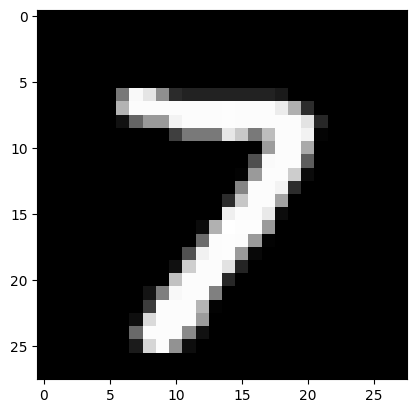

In [35]:
_ = plt.imshow(batch[0, 0], cmap='gray')

In [36]:
outputs = model(batch)
torch.max(outputs, dim=1).indices

tensor([7])

In [ ]:
app = Flask(__name__)
_ = CORS(app)


@app.route('/predict', methods=['POST'])
def index():
  img_arr = np.array(request.json.get('grid'), dtype=np.uint8)
  batch = transform(img_arr).unsqueeze(0)
  _ = model.eval()
  with torch.no_grad():
    outputs = model(batch)
    return jsonify({'digit': torch.max(outputs, dim=1).indices[0].item()})


# app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [04/May/2026 18:02:31] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [04/May/2026 18:02:31] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [04/May/2026 18:03:08] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:08] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:14] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:14] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:22] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:22] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:40] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:40] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:49] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:03:49] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:04:00] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 18:04:00] "POST /pr

(28, 28)

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0 255 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0 190 255 255 255 255 255 255 255 255 255  57   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0 255 255   0   0   0   0   0   0  63 255 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0 255 255   0   0   0   0   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0 255 255   0   0   0   0   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0 255 255   0   0   0   0   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0 255 255   0   0   0   0   0   0   0   0   0 255 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0 255 127   0   0   0   0   0   0   0  63 255 255   0   0   0   0   0   0   0   0   0   0   0   0 

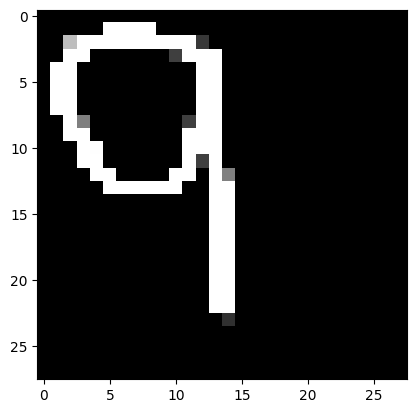

In [37]:
img_arr = np.array(json.load(open('img.json')), dtype=np.uint8)
img_arr.shape
print_pixel_grid(img_arr)
_ = plt.imshow(img_arr, cmap='gray')

In [38]:
batch = transform(img_arr).unsqueeze(0)
batch.shape
batch.min(), batch.max()

torch.Size([1, 1, 28, 28])

(tensor(-1.), tensor(1.))

In [39]:
_ = model.eval()
with torch.no_grad():
  outputs = model(batch)
  torch.max(outputs, dim=1).indices[0].item()

1